В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [1]:
import pandas as pd
medical_df = pd.read_csv('medical-charges.csv') # замініть на ваш шлях до файлу
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

In [3]:
non_smoker_df.head()

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160


### 1.

In [4]:
X = non_smoker_df["age"]
y = non_smoker_df["charges"]

In [ ]:
# charges = w * age + b -> θ=(XTX)−1XTy

In [5]:
X = non_smoker_df["age"].values.reshape(-1,1)

In [41]:
#X_design = np.array([[1, x[0]] for x in X])

In [7]:
def normal_equations(X,y):
    """Computes the closed-form solution to linear regression"""
    theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return theta

In [8]:
# Додаємо колонку одиничок аби задачи bias терм (константу в моделі регресії)
X_with_intercept = np.c_[np.ones((X.shape[0], 1)), X]
X[:3], X_with_intercept[:3]

(array([[18],
        [28],
        [33]], dtype=int64),
 array([[ 1., 18.],
        [ 1., 28.],
        [ 1., 33.]]))

In [9]:
MNK_coefs = normal_equations(X_with_intercept, y)

In [10]:
MNK_coefs

array([-2091.42055657,   267.24891283])

In [ ]:
# charges = -2091.42 + 267.25 * age

In [11]:
np.dot(X_with_intercept[0], MNK_coefs)

2719.059874396515

In [12]:
predictions_MNK = np.dot(X_with_intercept, MNK_coefs)

In [13]:
predictions_MNK[:3], y[:3]

(array([2719.0598744 , 5391.54900271, 6727.79356686]),
 1     1725.55230
 2     4449.46200
 3    21984.47061
 Name: charges, dtype: float64)

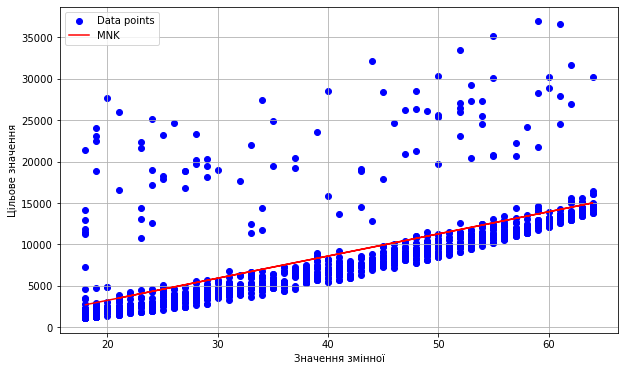

In [14]:
# Візуалізація результатів
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], y, color='blue', label='Data points')
plt.plot(X[:, 0], predictions_MNK, color='red', label='MNK')
plt.xlabel('Значення змінної')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()

### 2

In [ ]:
# 0.0001

In [16]:
# Градієнтний спуск
def full_batch_gradient_descent(X, y, lr=0.01, epochs=1000):
    m, b = 0.0, 0.0  # Початкові параметри
    n = len(y)
    errors = []
    for _ in range(epochs):
        y_pred = m * X[:, 0] + b
        error = y_pred - y
        errors.append(sum(error**2))
        m_gradient = (2/n) * np.dot(error, X[:, 0])
        b_gradient = (2/n) * np.sum(error)
        m = m - lr * m_gradient
        b = b - lr * b_gradient
    return m, b, errors

m, b, errors = full_batch_gradient_descent(X, y, lr=0.0001, epochs=1000)
predictions_fbgd = m * X[:, 0] + b

m, b

(221.1045843794301, -41.98126853149978)

In [18]:
y_hat = b + X*m

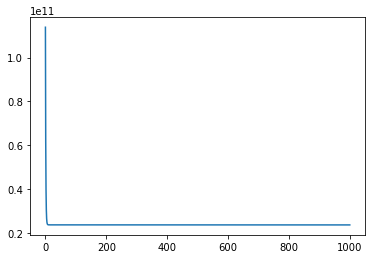

In [19]:
plt.plot(errors);

In [20]:
m, b, errors = full_batch_gradient_descent(X, y, lr=0.00001, epochs=1000)
predictions_fbgd = m * X[:, 0] + b
m, b

(220.15455551129122, 0.2130065279986326)

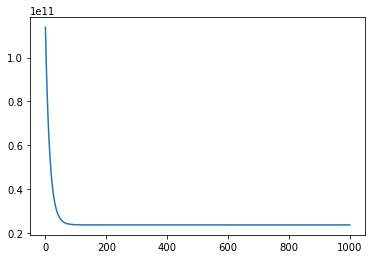

In [21]:
plt.plot(errors);

In [22]:
m, b, errors = full_batch_gradient_descent(X, y, lr=0.000001, epochs=1000)
predictions_fbgd = m * X[:, 0] + b
m, b

(213.4575690658104, 4.331249162394349)

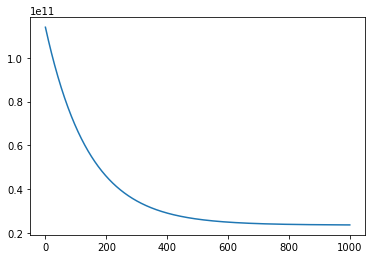

In [23]:
plt.plot(errors);

In [24]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

In [25]:
rmse_MNK = rmse(y, predictions_MNK)
print("RMSE MNK:", rmse_MNK)

RMSE MNK: 4662.505766636392


In [26]:
rmse_GD = rmse(y, predictions_fbgd)
print("RMSE GD:", rmse_GD)

RMSE GD: 4723.647721473958


In [27]:
!pip install scikit-learn --quiet



In [28]:
from sklearn.linear_model import LinearRegression

# Модель лінійної регресії засобами Scikit-learn (МНК)
lin_reg = LinearRegression()

In [29]:
lin_reg

LinearRegression()

In [30]:
lin_reg.fit(X, y)

LinearRegression()

In [31]:
lin_reg.coef_, lin_reg.intercept_

(array([267.24891283]), -2091.4205565650827)

In [32]:
predictions_sklearn = lin_reg.predict(X)

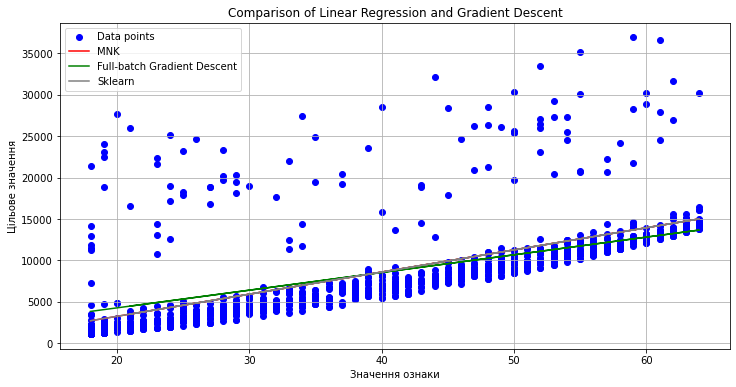

In [33]:
# Візуалізація результатів
plt.figure(figsize=(12, 6))
X_plot = non_smoker_df["age"].values
plt.scatter(X_plot, y, color='blue', label='Data points')
plt.plot(X_plot, predictions_MNK, color='red', label='MNK')
plt.plot(X_plot, predictions_fbgd, color='green', label='Full-batch Gradient Descent')
plt.plot(X_plot, predictions_sklearn, color='grey', label='Sklearn')
plt.title('Comparison of Linear Regression and Gradient Descent')
plt.xlabel('Значення ознаки')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()

In [34]:
X_np = non_smoker_df["age"].values.reshape(-1, 1)
X_plot = non_smoker_df["age"].values

Learning rate = 0.0001
m = 221.1045843794301
b = -41.98126853149978
RMSE = 4713.250582815521


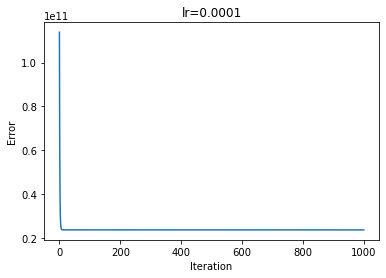

Learning rate = 1e-05
m = 220.15455551129122
b = 0.2130065279986326
RMSE = 4715.349750127829


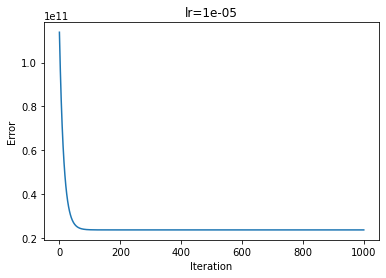

Learning rate = 1e-06
m = 213.4575690658104
b = 4.331249162394349
RMSE = 4723.647721473958


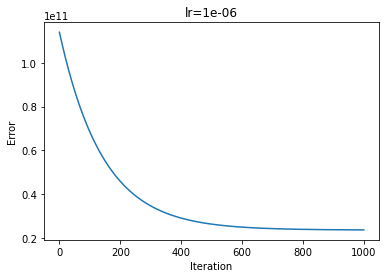

In [35]:
for lr in [0.0001, 0.00001, 0.000001]:

    m, b, errors = full_batch_gradient_descent(X_np, y, lr=lr, epochs=1000)

    predictions = m * X_plot + b

    print("Learning rate =", lr)
    print("m =", m)
    print("b =", b)
    print("RMSE =", rmse(y, predictions))

    plt.figure()
    plt.plot(errors)
    plt.title(f"lr={lr}")
    plt.xlabel("Iteration")
    plt.ylabel("Error")
    plt.show()

### Висновок:


In [37]:
###Серед протестованих значень learning rate = 0.0001 показав найменше значення RMSE та найшвидшу збіжність.

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [38]:
smoker_df = medical_df[medical_df["smoker"] == "yes"]

X_smoker = smoker_df[["age"]]
y_smoker = smoker_df["charges"]



model_smoker = LinearRegression()

model_smoker.fit(X_smoker, y_smoker)

predictions_smoker = model_smoker.predict(X_smoker)

rmse_smoker = rmse(y_smoker, predictions_smoker)

print("Коефіцієнт:", model_smoker.coef_[0])
print("Intercept:", model_smoker.intercept_)
print("RMSE:", rmse_smoker)

Коефіцієнт: 305.23760210982886
Intercept: 20294.128126915966
RMSE: 10711.00334810241


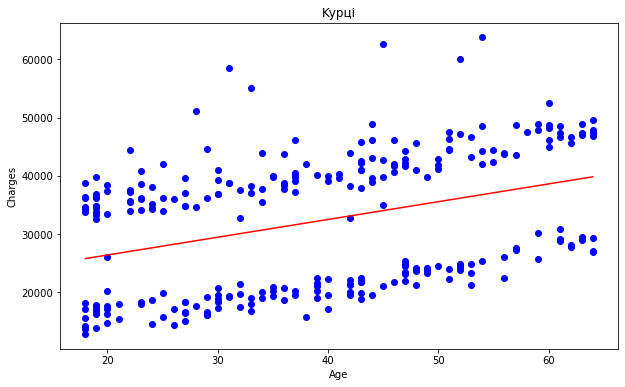

In [49]:
plt.figure(figsize=(10,6))

plt.scatter(
    smoker_df["age"],
    y_smoker,
    color="blue",
    label="Data"
)

idx = np.argsort(smoker_df["age"].values)

plt.plot(
    smoker_df["age"].values[idx],
    predictions_smoker[idx],
    color="red",
    label="лінійна регресія"
)

plt.title("Kурці")
plt.xlabel("Age")
plt.ylabel("Charges")


plt.show()

### Лінійна регресія показує позитивний зв'язок між віком та Charges серед курців. Із збільшенням віку середній розмір Charges зростає. Hа вартість charges також впливають інші фактори: BMI, кількість дітей або регіон.